# Lab: Linear Regression
Chapter 3 of Introduction to Statistical Learning

#### Libraries

In [1]:
# Importing standard libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [2]:
# New libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [3]:
# Functions from the ISLP package
from ISLP import load_data
from ISLP.models import (ModelSpec as MS, summarize, poly)

In [ ]:
# Function that provides a list of objects in a namespace
dir()

In [ ]:
# dir() also shows attributes and methods of an object
A = np.array([3,5,11])
dir(A)

In [ ]:
A.sum()

#### Simple Linear Regression

In [4]:
# Loading the Boston data set from ISLP
Boston = load_data("Boston")        # Loads Boston as a pandas data frame
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

The Boston data set records "medv" (median house value) for 506 neighborhoods around Boston. We will build a regression model to predict medv using 13 predictors annd statsmodels.

In [6]:
# sm.OLS() fits a simple linear regression model. In this case our response is medv and lstat will be the predictor
# First we create the model matrix by hand
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [7]:
# We extract the response and fit the model
y = Boston['medv']
model = sm.OLS(y, X)                # sm.OLS doesn't fit the model, it specifies the model
results = model.fit()               # the .fit() method actually fits the model

In [ ]:
# ISLP package function 'sumarize()'
summarize(results)

A 'transform' is an object with two main methods: fit() and transform() used to construct a corresponding model matrix using ModelSpec() (renamed MS() when imported)

In [8]:
# We create the model matrix again, but with a different method
design = MS(['lstat'])              # Specifies a variable, in this case 'lstat'
design = design.fit(Boston)         # Checks that the variable exists in the data frame Boston
X = design.transform(Boston)        # Constructs the model matrix with two columns: intercept and the variable lstat
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [9]:
# The same result can be achieved using only the fit_transform() method
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [10]:
# In contrast to the summarize() function, the summary() method gives a full and more exhaustive summary of the fit
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           5.08e-88
Time:                        16:05:25   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
# Retrieves the fitted coefficients with the params attibute of results
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

We will use the 'get_prediction()' method to obtain predictions. First we will crate a new data frame containing only the variable lstat, with the values of the variable at which we wish to make predictions.

In [12]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})        # 'variable name':[values to test]
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [13]:
# We compute the predictions and view them with the predicted_mean attribute
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [14]:
# We produce confidence intervals for the predicted values
new_predictions.conf_int(alpha=0.05)            # alpha indicates the % (1-alpha), in this case we compute the 95% CI 

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [15]:
# Prediction intervals are computed by setting obs=True
new_predictions.conf_int(obs=True, alpha=0.05) 

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [16]:
# Function that adds a line to an existing plot
def abline(ax, b, m, *args, **kwargs):
    # *args = any number of non-named arguments
    # **kwargs = any number of named arguments
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

C:\Users\vavic\AppData\Local\Temp\ipykernel_14248\353414639.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[0],           # Intercept (coeficient B0)
C:\Users\vavic\AppData\Local\Temp\ipykernel_14248\353414639.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  results.params[1],           # Slope (coeficient B1)


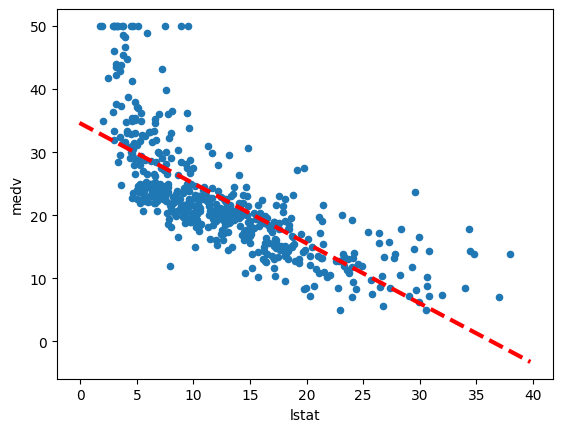

In [17]:
# We use our new function to add the regression line to a plot of medv vs lstat
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax,
       results.params[0],           # Intercept (coeficient B0)
       results.params[1],           # Slope (coeficient B1)
       'r--',                       # Produces a red dashed line
       linewidth=3) 

Next we examine some diagnostic plots:

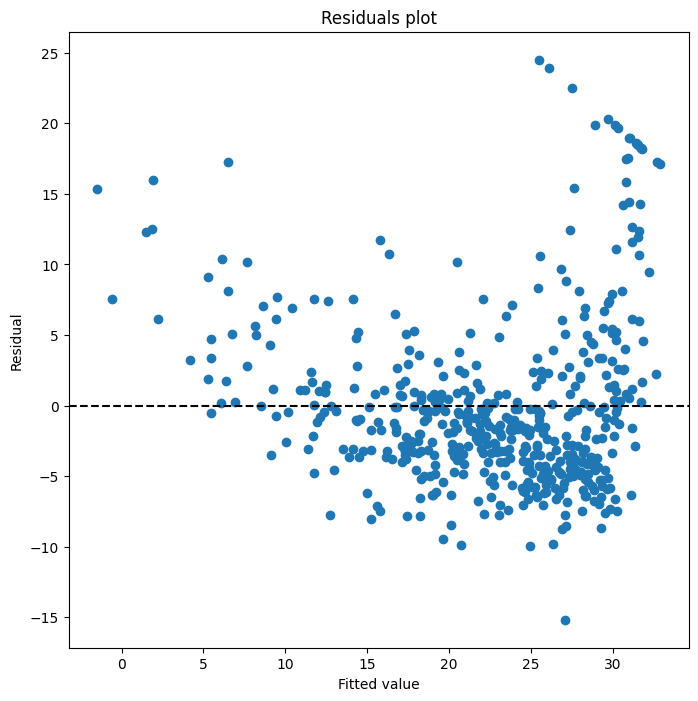

In [18]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues, results.resid)
ax.set_title('Residuals plot')
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')           # Adds a horizontal line at 0

The figure suggests that there´s some evidence of non-linearity. We now procede to compute the Leverage statistic using the 'hat_matrix-diag' attribute of the value returned by the 'get_influence' method.

np.int64(374)

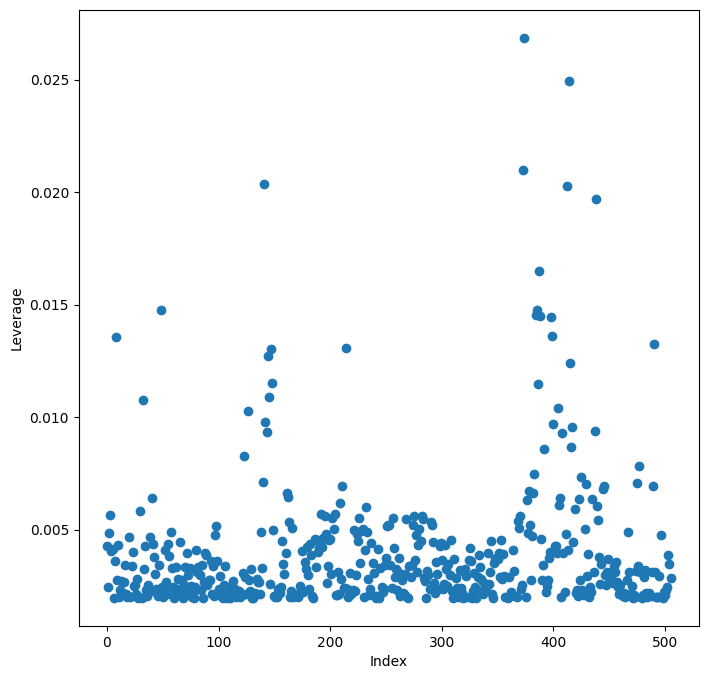

In [19]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)             # Identifies the index of the largest element of an array

#### Multiple Linear Regression

First we'll use the ModelSpec() transform to construct the model matrix and response. First we´ll fit two variables, lstat and age.

In [32]:
X = MS(['lstat', 'age']).fit_transform(Boston)          # Creates the model matrix
model1 = sm.OLS(y, X)                                   # Creates the model using sm.OLS
results1 = model1.fit()                                 # Fits the results
summarize(results1)                                     # Prints a summary of the results        

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [ ]:
# Creates a list with all the columns in the Boston data set except medv
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='object')

Now we can fit the model with all the variables in terms using the same model matrix builder

In [22]:
X = MS(terms).fit_transform(Boston)                     # Creates the model matrix
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


In the above regression model, the variable age has a high p-value. So we may wish to run a regression without this predictor as follows

In [ ]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit()) 

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


#### Multivariate Goodness of Fit
We can access individual components of results by name. The method results.rsquared gives us the $R^2$, and np.sqrt(results.scale) gives us the $RSE$. We will also compute the $VIF$.
#### List Comprehension
List comprehensions are ways t oform lists of Python objects. For example, we compute the $VIF$ for each of the variables in the model matrix X, using the function variance_inflation_factor() (renamed VIF at the start of the notebook).

In [ ]:
vals = [VIF(X, i)                                       # VIF takes a dataframe or array and a varialbe column index as arguments
        for i in range(1, X.shape[1])]                  # We exclude the value at 0 (intercept)
vif = pd.DataFrame({'vif':vals},                        # We make it into a dataframe
                   index=X.columns[1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


#### Interaction Terms
We´ll use ModelSpec() to include interaction terms. We do this by adding a tuple ("lstat"."age") that thells the model matrix builder to include an interaction term between those two variables.

In [29]:
X = MS(['lstat', 'age', ('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


#### Non-linear Transfrmations of the Predictors
The model matrix can include other terms outside of column names and interactions. THe ISLP poly() function specifies that columns representing polynomial functions of its first argument are added to the model matrix.

In [30]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


The fact that the p-value for the cuadratic term is effectively zero, and this tells us that this led to an improved model.
We use the anova_lm() function to quantify the extent to which the quadratic fit is superior to the linear fit.

In [33]:
anova_lm(results1, results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


results1 represents the linear submodel containing predictors lstat and age, while results3 is the larger model above with a quadratic term in lstat. anova_lm() performs a hypothesis test comaring the two models. $H_{0}$ is that the quadratic term is not needed, and $H_{a}$ is that the bigger model is superior. The F-statistic is 177.28 and the associated p-value is practically zero. In this case the F-statistic is the square of the t-statistic for the quadratic term in the linear model for results3.
Thus there´s clear evidence that the quadratic polynomial improves the linear model. 
anova_lm() can take more than two nested models as input, and in this case it compares every successive pair. Thats why there's NaN's in the first row, as there's no previous model to compare to.

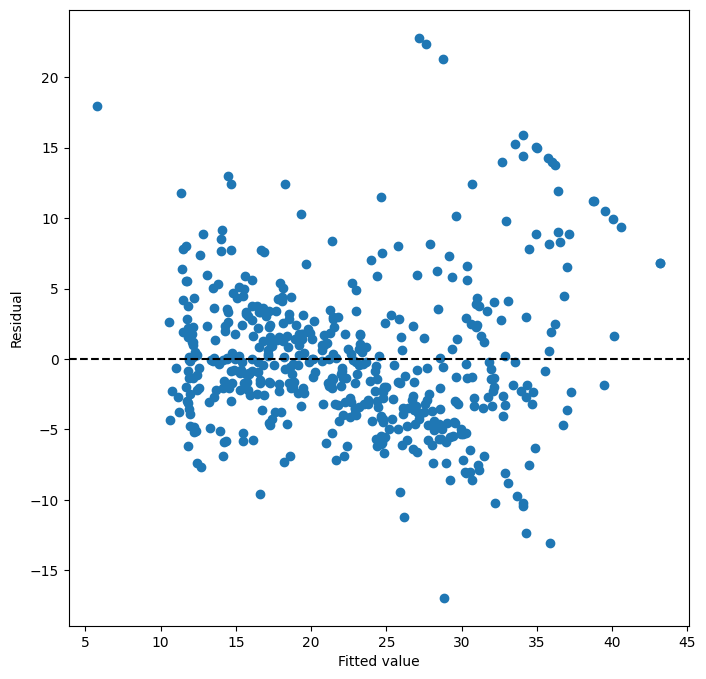

In [ ]:
# We produce a Residuals plot for the quadratic model
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues, results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--')

#### Qualitative Predictors
Now we'll use the Carseats data. We will attempt to predict Sales (child car seat sales) in 400 locations based on a number of predictors.

In [35]:
Carseats = load_data('Carseats')
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

The data includes qualitative predictors such as ShelveLoc, an indicator of the quality of the shelving location. It takes three possible values, Bad, Medium and Good. ModelSpec() generattets dummy vaiables automatically. The solumn ShelveLoc[Bad] will be dropped, since Bad is the first level of ShelveLoc. We'll fit a multiple regression model that includes some intaractoin terms:

In [36]:
allvars = list(Carseats.columns.drop('Sales'))                  # Creates a list of all columns except sales
y = Carseats['Sales']                                           # Creates the response matrix
# Adds interaction variables between income-advertising, and between price-age
final = allvars + [('Income', 'Advertising'),        
                   ('Price', 'Age')]
X = MS(final).fit_transform(Carseats)                           # Creates the model matrix
model = sm.OLS(y, X)                                            # Creates the model
summarize(model.fit())                                          # Summary of the model

,coef,std err,t,P>|t|
intercept,6.5756,1.009,6.519,0.000
CompPrice,0.0929,0.004,22.567,0.000
Income,0.0109,0.003,4.183,0.000
Advertising,0.0702,0.023,3.107,0.002
Population,0.0002,0.000,0.433,0.665
Price,-0.1008,0.007,-13.549,0.000
ShelveLoc[Good],4.8487,0.153,31.724,0.000
ShelveLoc[Medium],1.9533,0.126,15.531,0.000
Age,-0.0579,0.016,-3.633,0.000
Education,-0.0209,0.020,-1.063,0.288
